# LeiGS 2026 — Proctor Prediction Challenge · v2
**Goal**: Predict `proctor_mdd_g_cm3` (MDD) and `proctor_owc_pct` (OWC) from soil classification features.

**v2 additions**: SHAP global/local explanations + SHAPIQ pairwise feature-interaction analysis for feature correlation discovery and feature selection guidance.

**Metric**: NMAE = 0.5×(MAE_mdd/IQR_mdd) + 0.5×(MAE_owc/IQR_owc)

## Section 0: Setup & Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime

from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

import shap
import shapiq

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
np.random.seed(42)

IQR_MDD = 0.198
IQR_OWC = 3.860
RHO_W   = 1.0

print(f'shap {shap.__version__}  |  shapiq {shapiq.__version__}')
print('All imports OK')

## Section 1: Data Loading

In [4]:
train_raw  = pd.read_csv('../data/train.csv')
test_raw   = pd.read_csv('../data/test.csv')
sample_sub = pd.read_csv('../sample_submission.csv')

print(f'Train: {train_raw.shape}  |  Test: {test_raw.shape}')
train_raw.head(3)

Train: (201, 25)  |  Test: (87, 23)


,id,psd_size_at_d10_mm,psd_size_at_d20_mm,psd_size_at_d30_mm,psd_size_at_d40_mm,psd_size_at_d50_mm,psd_size_at_d60_mm,psd_size_at_d70_mm,psd_size_at_d80_mm,psd_size_at_d90_mm,...,psd_passing_at_2mm_pct,proctor_mdd_g_cm3,proctor_owc_pct,proctor_diam_mm,grain_density_g_cm3,hyd_cond_kf_m_s,hyd_cond_hyd_gradient,atterberg_liquid_limit_pct,atterberg_plastic_limit_pct,loss_on_ignition_pct
0,0,0.136773,0.315214,0.547515,0.933930,1.788142,3.313938,7.214010,12.517275,20.160863,...,51.68,2.068,8.06,150,2.650,NaN,NaN,NaN,NaN,NaN
1,1,0.014579,0.062060,0.119258,0.221877,0.423550,1.022249,2.978369,6.081199,10.622063,...,65.49,2.037,10.42,100,2.690,NaN,NaN,NaN,NaN,1.3
2,2,0.003243,0.022301,0.087024,0.156595,0.217595,0.323793,0.512853,1.546115,10.921905,...,81.40,2.051,10.94,100,2.722,1.400000e-10,30.0,26.45,13.75,NaN


## Section 2: Preprocessing

In [5]:
TARGET_COLS = ['proctor_mdd_g_cm3', 'proctor_owc_pct']

PSD_D_COLS = [
    'psd_size_at_d10_mm', 'psd_size_at_d20_mm', 'psd_size_at_d30_mm',
    'psd_size_at_d40_mm', 'psd_size_at_d50_mm', 'psd_size_at_d60_mm',
    'psd_size_at_d70_mm', 'psd_size_at_d80_mm', 'psd_size_at_d90_mm',
    'psd_size_at_d95_mm', 'psd_size_at_d98_mm'
]

HIGH_MISSING = [
    'atterberg_liquid_limit_pct', 'atterberg_plastic_limit_pct',
    'hyd_cond_kf_m_s', 'hyd_cond_hyd_gradient', 'loss_on_ignition_pct'
]

def preprocess(df, medians=None, fit=False):
    df = df.copy()
    df['psd_has_sedimentation'] = df['psd_has_sedimentation'].map(
        {True: 1, False: 0, 'True': 1, 'False': 0}
    ).astype(float)
    for col in PSD_D_COLS + HIGH_MISSING + [
        'psd_passing_at_0_002mm_pct', 'psd_passing_at_0_063mm_pct',
        'psd_passing_at_2mm_pct', 'grain_density_g_cm3', 'proctor_diam_mm'
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    for col in HIGH_MISSING:
        df[f'{col}_missing'] = df[col].isna().astype(int)
    if fit:
        medians = {col: df[col].median() for col in HIGH_MISSING}
    for col in HIGH_MISSING:
        df[col] = df[col].fillna(medians[col])
    return df, medians

train_pp, medians = preprocess(train_raw, fit=True)
test_pp, _        = preprocess(test_raw, medians=medians, fit=False)
print('Preprocessing complete.')

Preprocessing complete.


## Section 3: Feature Engineering

In [6]:
def engineer_features(df):
    df = df.copy()
    D10 = df['psd_size_at_d10_mm'].replace(0, np.nan)
    D30 = df['psd_size_at_d30_mm']
    D60 = df['psd_size_at_d60_mm'].replace(0, np.nan)

    df['feat_cu']     = D60 / D10
    df['feat_cc']     = (D30 ** 2) / (D60 * D10)
    df['feat_log_cu'] = np.log1p(df['feat_cu'])
    df['feat_pi']     = df['atterberg_liquid_limit_pct'] - df['atterberg_plastic_limit_pct']

    df['feat_sand_pct']            = (df['psd_passing_at_2mm_pct'] - df['psd_passing_at_0_063mm_pct']).clip(lower=0)
    df['feat_gravel_pct']          = (100 - df['psd_passing_at_2mm_pct']).clip(lower=0)
    df['feat_clay_to_fines_ratio'] = (
        df['psd_passing_at_0_002mm_pct']
        / df['psd_passing_at_0_063mm_pct'].replace(0, np.nan)
    ).fillna(0)
    df['feat_soil_type'] = pd.cut(
        df['psd_passing_at_0_063mm_pct'], bins=[-1, 10, 40, 101], labels=[0, 1, 2]
    ).astype(float)

    rho_s = df['grain_density_g_cm3']
    w_est = (df['psd_passing_at_0_063mm_pct'] / 10).clip(lower=3)
    df['feat_sat_mdd_proxy'] = rho_s / (1 + (w_est / 100) * rho_s / RHO_W)
    df['feat_d50'] = df['psd_size_at_d50_mm']

    for col in PSD_D_COLS:
        df[f'log_{col}'] = np.log1p(df[col])
    df['log_hyd_cond_kf_m_s'] = np.log1p(df['hyd_cond_kf_m_s'])
    return df

train_fe = engineer_features(train_pp)
test_fe  = engineer_features(test_pp)

EXCLUDE      = ['id'] + TARGET_COLS
FEATURE_COLS = [c for c in train_fe.columns if c not in EXCLUDE]

X_train = train_fe[FEATURE_COLS].values.astype(np.float32)
y_mdd   = train_fe['proctor_mdd_g_cm3'].values
y_owc   = train_fe['proctor_owc_pct'].values
X_test  = test_fe[FEATURE_COLS].values.astype(np.float32)

X_train_df = train_fe[FEATURE_COLS]   # keep DataFrame for SHAP plots
X_test_df  = test_fe[FEATURE_COLS]

print(f'Features: {len(FEATURE_COLS)}  |  X_train: {X_train.shape}  X_test: {X_test.shape}')

Features: 49  |  X_train: (201, 49)  X_test: (87, 49)


## Section 4: Metric & Baseline

In [7]:
def nmae(y_mdd_true, y_owc_true, y_mdd_pred, y_owc_pred):
    mae_mdd = np.mean(np.abs(y_mdd_true - y_mdd_pred))
    mae_owc = np.mean(np.abs(y_owc_true - y_owc_pred))
    return 0.5 * (mae_mdd / IQR_MDD) + 0.5 * (mae_owc / IQR_OWC)

def cv_nmae(model_mdd, model_owc, X, y_mdd, y_owc, n_splits=5, label=''):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        model_mdd.fit(X[tr_idx], y_mdd[tr_idx])
        model_owc.fit(X[tr_idx], y_owc[tr_idx])
        score = nmae(y_mdd[val_idx], y_owc[val_idx],
                     model_mdd.predict(X[val_idx]),
                     model_owc.predict(X[val_idx]))
        scores.append(score)
        print(f'  [{label}] Fold {fold+1}: {score:.4f}')
    print(f'  Mean: {np.mean(scores):.4f} ± {np.std(scores):.4f}')
    return scores

## Section 5: Train XGBoost & LightGBM (full-train fit for SHAP)

In [8]:
xgb_params = dict(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbosity=0
)
lgb_params = dict(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbose=-1
)

print('--- 5-fold CV: XGBoost ---')
xgb_mdd_cv = xgb.XGBRegressor(**xgb_params)
xgb_owc_cv = xgb.XGBRegressor(**xgb_params)
xgb_scores = cv_nmae(xgb_mdd_cv, xgb_owc_cv, X_train, y_mdd, y_owc, label='XGB')

print('\n--- 5-fold CV: LightGBM ---')
lgb_mdd_cv = lgb.LGBMRegressor(**lgb_params)
lgb_owc_cv = lgb.LGBMRegressor(**lgb_params)
lgb_scores = cv_nmae(lgb_mdd_cv, lgb_owc_cv, X_train, y_mdd, y_owc, label='LGB')

# Full-train fit (for SHAP)
xgb_mdd = xgb.XGBRegressor(**xgb_params).fit(X_train, y_mdd)
xgb_owc = xgb.XGBRegressor(**xgb_params).fit(X_train, y_owc)
lgb_mdd = lgb.LGBMRegressor(**lgb_params).fit(X_train, y_mdd)
lgb_owc = lgb.LGBMRegressor(**lgb_params).fit(X_train, y_owc)
print('\nFull-train models fitted.')

--- 5-fold CV: XGBoost ---
  [XGB] Fold 1: 0.2622
  [XGB] Fold 2: 0.2464
  [XGB] Fold 3: 0.2851
  [XGB] Fold 4: 0.2916
  [XGB] Fold 5: 0.2209
  Mean: 0.2612 ± 0.0258

--- 5-fold CV: LightGBM ---
  [LGB] Fold 1: 0.2738
  [LGB] Fold 2: 0.2427
  [LGB] Fold 3: 0.2937
  [LGB] Fold 4: 0.2757
  [LGB] Fold 5: 0.2281
  Mean: 0.2628 ± 0.0239

Full-train models fitted.


---
## Section 6: SHAP Global Feature Importance
TreeExplainer gives exact SHAP values for tree ensembles in O(TLD) time.

In [9]:
explainer_xgb_mdd = shap.TreeExplainer(xgb_mdd)
explainer_xgb_owc = shap.TreeExplainer(xgb_owc)
explainer_lgb_mdd = shap.TreeExplainer(lgb_mdd)
explainer_lgb_owc = shap.TreeExplainer(lgb_owc)

sv_xgb_mdd = explainer_xgb_mdd(X_train_df)   # SHAP Explanation object
sv_xgb_owc = explainer_xgb_owc(X_train_df)
sv_lgb_mdd = explainer_lgb_mdd(X_train_df)
sv_lgb_owc = explainer_lgb_owc(X_train_df)

print('SHAP values computed.')
print(f'Shape (XGB MDD): {sv_xgb_mdd.values.shape}  → (samples × features)')

SHAP values computed.
Shape (XGB MDD): (201, 49)  → (samples × features)


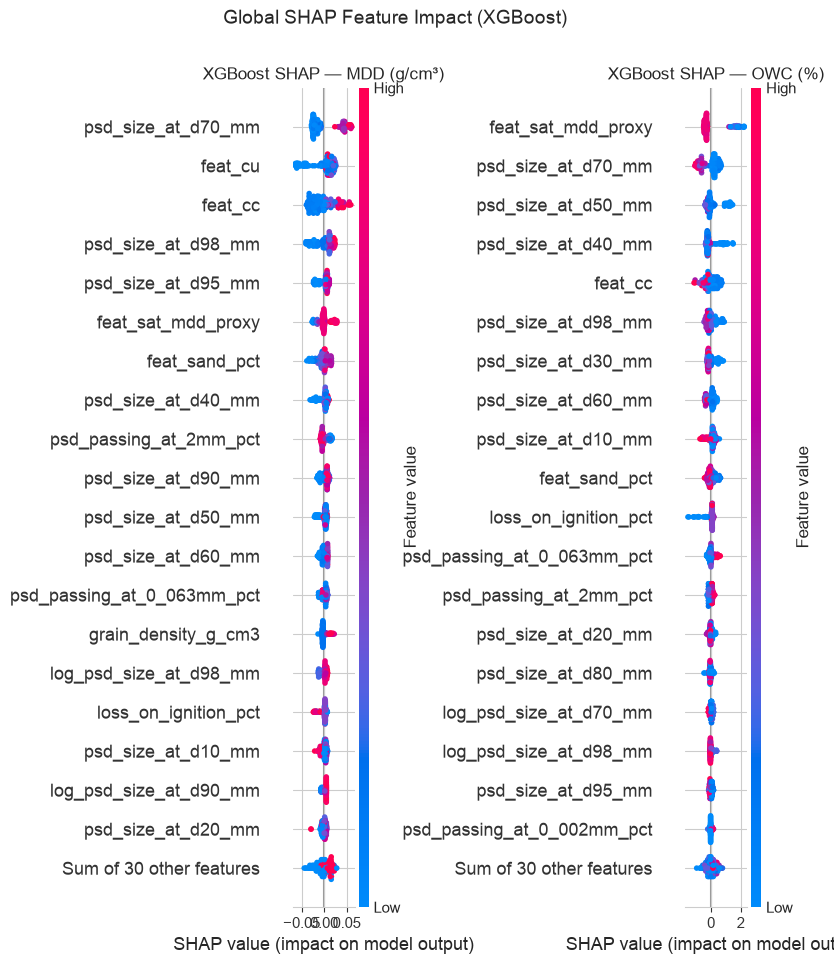

In [10]:
# --- Beeswarm: top-20 features for both targets, side by side ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plt.sca(axes[0])
shap.plots.beeswarm(sv_xgb_mdd, max_display=20, show=False)
axes[0].set_title('XGBoost SHAP — MDD (g/cm³)', fontsize=12)

plt.sca(axes[1])
shap.plots.beeswarm(sv_xgb_owc, max_display=20, show=False)
axes[1].set_title('XGBoost SHAP — OWC (%)', fontsize=12)

plt.suptitle('Global SHAP Feature Impact (XGBoost)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

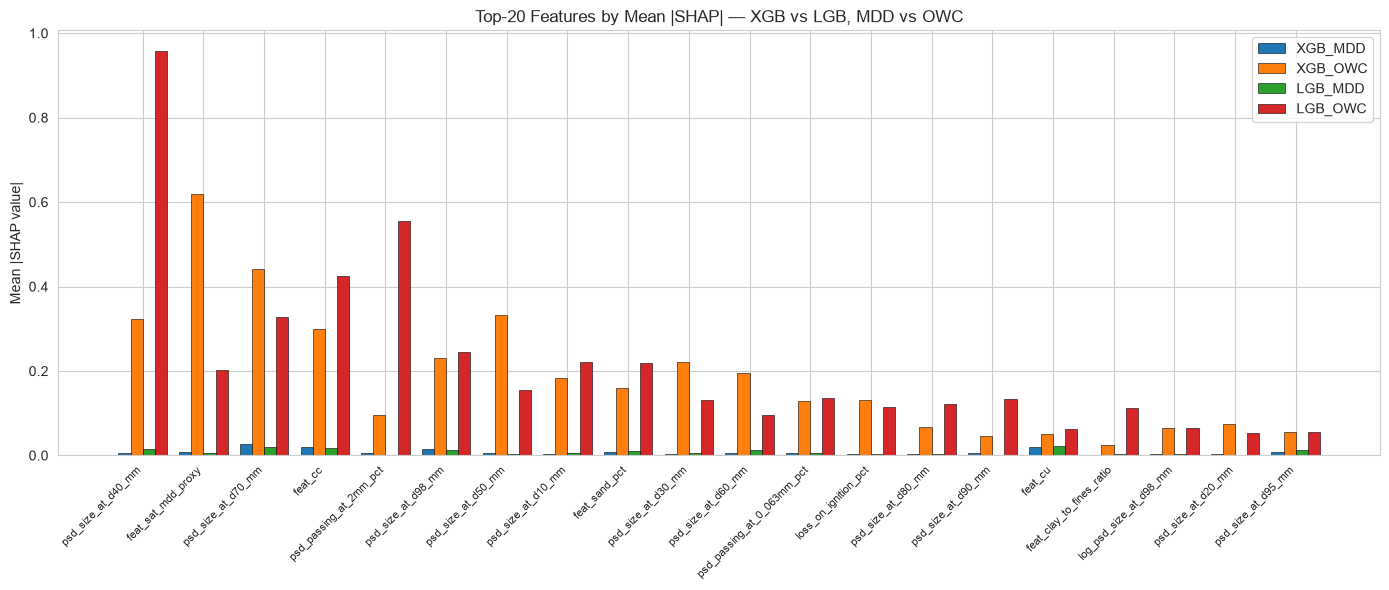

Top-10 overall:
                        XGB_MDD  XGB_OWC  LGB_MDD  LGB_OWC  mean_all
psd_size_at_d40_mm       0.0068   0.3225   0.0151   0.9585    0.3257
feat_sat_mdd_proxy       0.0083   0.6194   0.0061   0.2032    0.2092
psd_size_at_d70_mm       0.0271   0.4418   0.0200   0.3284    0.2043
feat_cc                  0.0197   0.3001   0.0186   0.4247    0.1908
psd_passing_at_2mm_pct   0.0063   0.0968   0.0020   0.5560    0.1653
psd_size_at_d98_mm       0.0153   0.2313   0.0135   0.2438    0.1260
psd_size_at_d50_mm       0.0051   0.3317   0.0022   0.1539    0.1232
psd_size_at_d10_mm       0.0041   0.1824   0.0050   0.2210    0.1031
feat_sand_pct            0.0082   0.1589   0.0105   0.2197    0.0993
psd_size_at_d30_mm       0.0025   0.2218   0.0059   0.1319    0.0905


In [11]:
# --- Bar chart: mean |SHAP| for XGB vs LGB, both targets ---
def mean_abs_shap(sv):
    return pd.Series(np.abs(sv.values).mean(axis=0), index=FEATURE_COLS)

shap_imp = pd.DataFrame({
    'XGB_MDD': mean_abs_shap(sv_xgb_mdd),
    'XGB_OWC': mean_abs_shap(sv_xgb_owc),
    'LGB_MDD': mean_abs_shap(sv_lgb_mdd),
    'LGB_OWC': mean_abs_shap(sv_lgb_owc),
})
shap_imp['mean_all'] = shap_imp.mean(axis=1)
shap_imp = shap_imp.sort_values('mean_all', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
top = shap_imp.head(20)
x   = np.arange(len(top))
w   = 0.2
for i, col in enumerate(['XGB_MDD', 'XGB_OWC', 'LGB_MDD', 'LGB_OWC']):
    ax.bar(x + i*w, top[col], width=w, label=col, edgecolor='k', linewidth=0.4)
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(top.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean |SHAP value|')
ax.set_title('Top-20 Features by Mean |SHAP| — XGB vs LGB, MDD vs OWC')
ax.legend()
plt.tight_layout()
plt.show()

print('Top-10 overall:')
print(shap_imp[['XGB_MDD','XGB_OWC','LGB_MDD','LGB_OWC','mean_all']].head(10).round(4))

---
## Section 7: SHAP Dependence Plots — Top Features
Scatter of SHAP value vs feature value, coloured by the most-interacting feature (auto-selected).

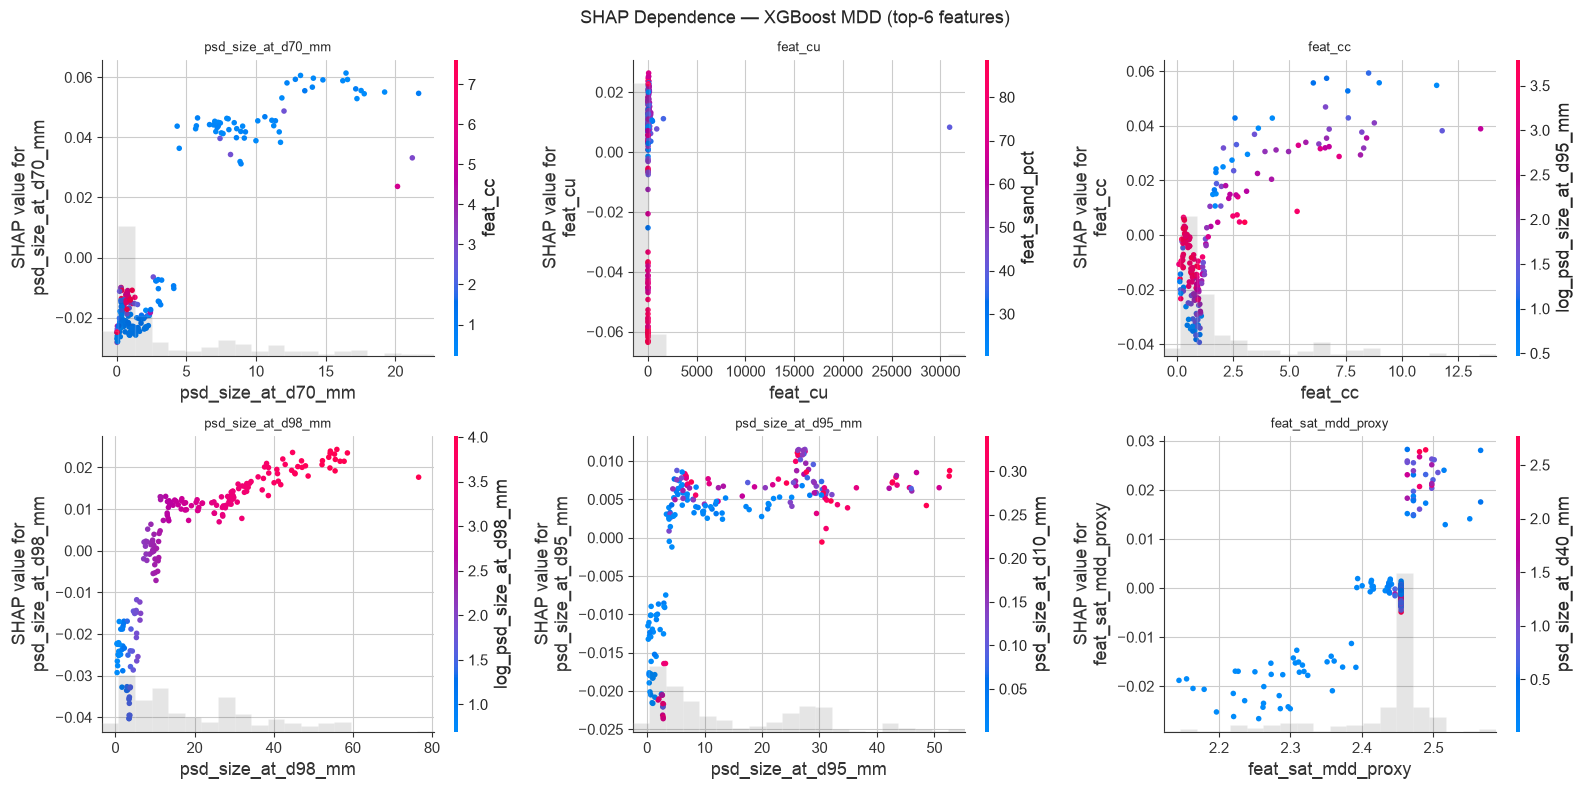

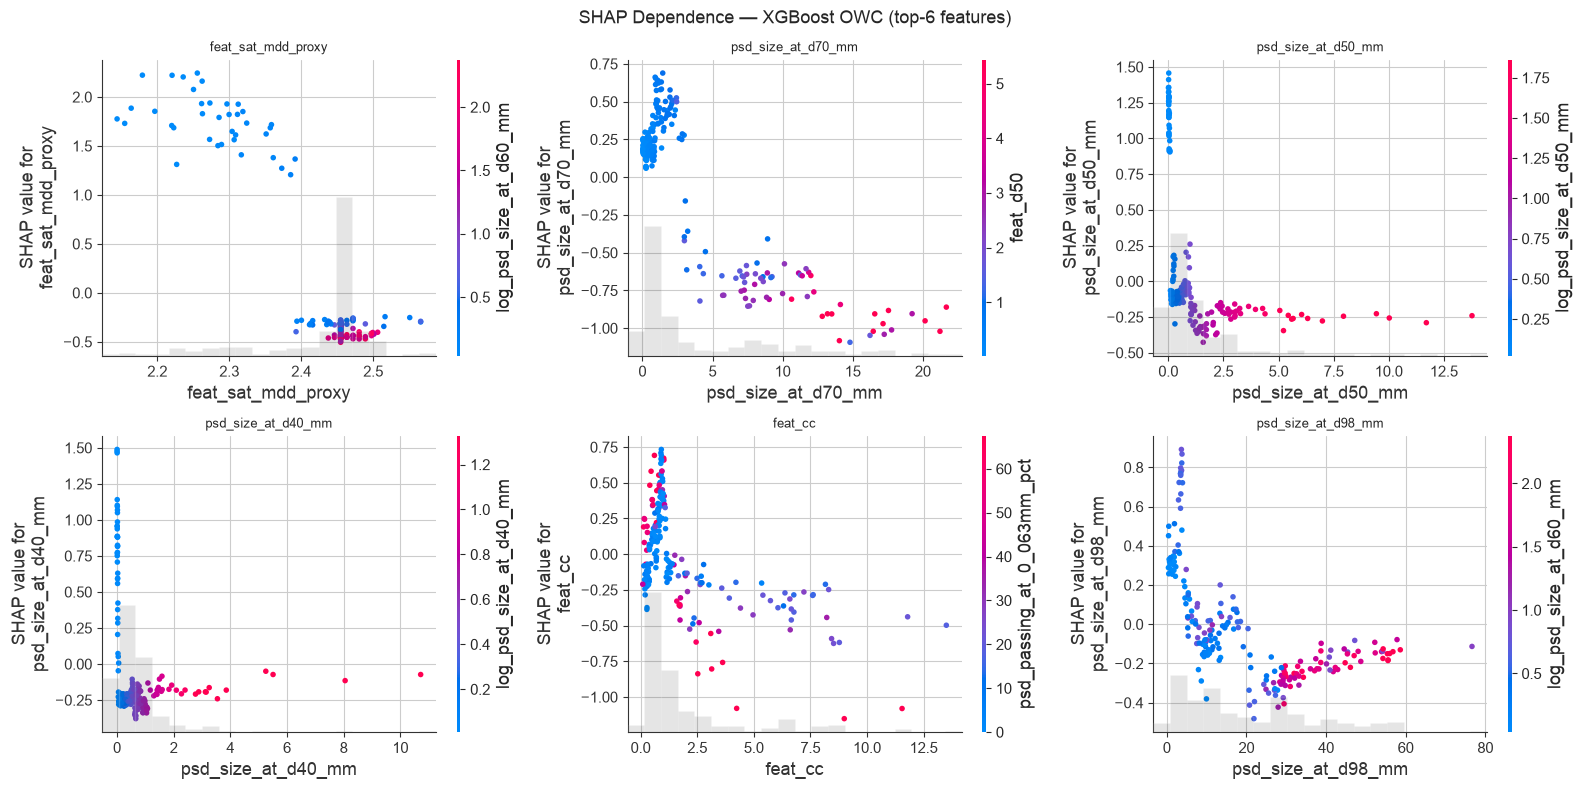

In [12]:
top_features_mdd = shap_imp['XGB_MDD'].nlargest(6).index.tolist()
top_features_owc = shap_imp['XGB_OWC'].nlargest(6).index.tolist()

for target_label, sv, top_feats in [
    ('MDD', sv_xgb_mdd, top_features_mdd),
    ('OWC', sv_xgb_owc, top_features_owc)
]:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, feat in zip(axes.flat, top_feats):
        plt.sca(ax)
        shap.plots.scatter(sv[:, feat], color=sv, ax=ax, show=False)
        ax.set_title(feat, fontsize=9)
    fig.suptitle(f'SHAP Dependence — XGBoost {target_label} (top-6 features)', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## Section 8: SHAP-based Feature Correlation Analysis
Features whose SHAP vectors are highly correlated tend to carry redundant information.
We compute pairwise Pearson correlation of SHAP value columns and plot as a heatmap.


---
## Section 8b: SHAP Interaction Values (TreeExplainer — exact & fast)
`shap_interaction_values` returns an (n × features × features) tensor.
- Diagonal `[i, i]` = main SHAP effect of feature *i*  
- Off-diagonal `[i, j]` = interaction effect of the pair *(i, j)*

This uses XGBoost's exact tree path enumeration — much faster than sampling-based methods for large feature sets.


Computing SHAP interaction values (XGBoost MDD & OWC)...
Interaction tensor shape: (201, 49, 49)


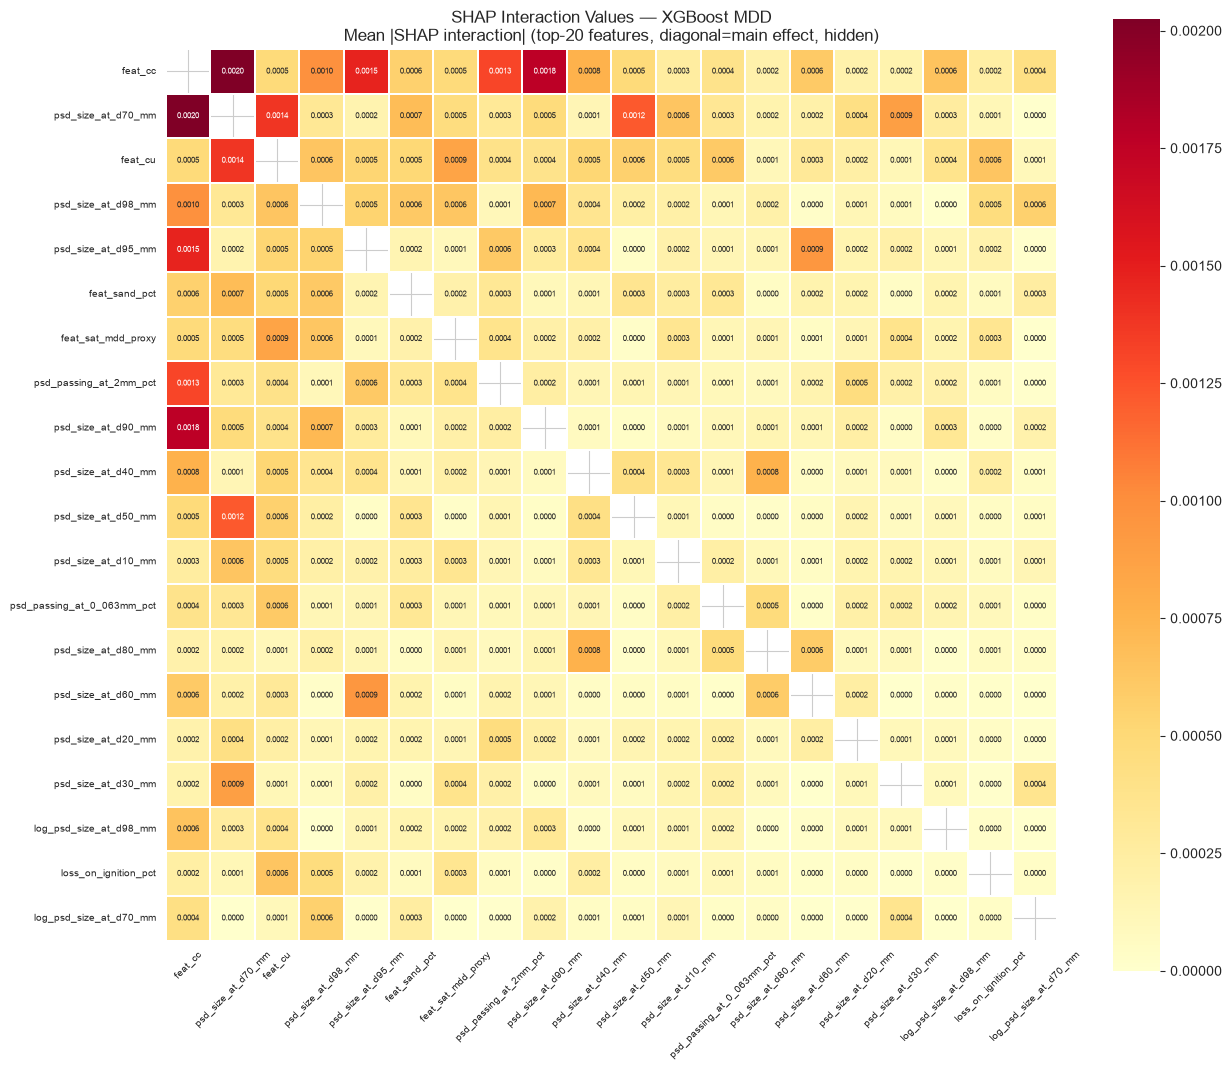


MDD — Top-10 SHAP interaction pairs:
  feat_cc  ×  psd_size_at_d70_mm  =  0.00202
  feat_cc  ×  psd_size_at_d90_mm  =  0.00176
  feat_cc  ×  psd_size_at_d95_mm  =  0.00148
  psd_size_at_d70_mm  ×  feat_cu  =  0.00139
  feat_cc  ×  psd_passing_at_2mm_pct  =  0.00131
  psd_size_at_d70_mm  ×  psd_size_at_d50_mm  =  0.00122
  feat_cc  ×  psd_size_at_d98_mm  =  0.00099
  psd_size_at_d95_mm  ×  psd_size_at_d60_mm  =  0.00094
  psd_size_at_d70_mm  ×  psd_size_at_d30_mm  =  0.00089
  feat_cu  ×  feat_sat_mdd_proxy  =  0.00086


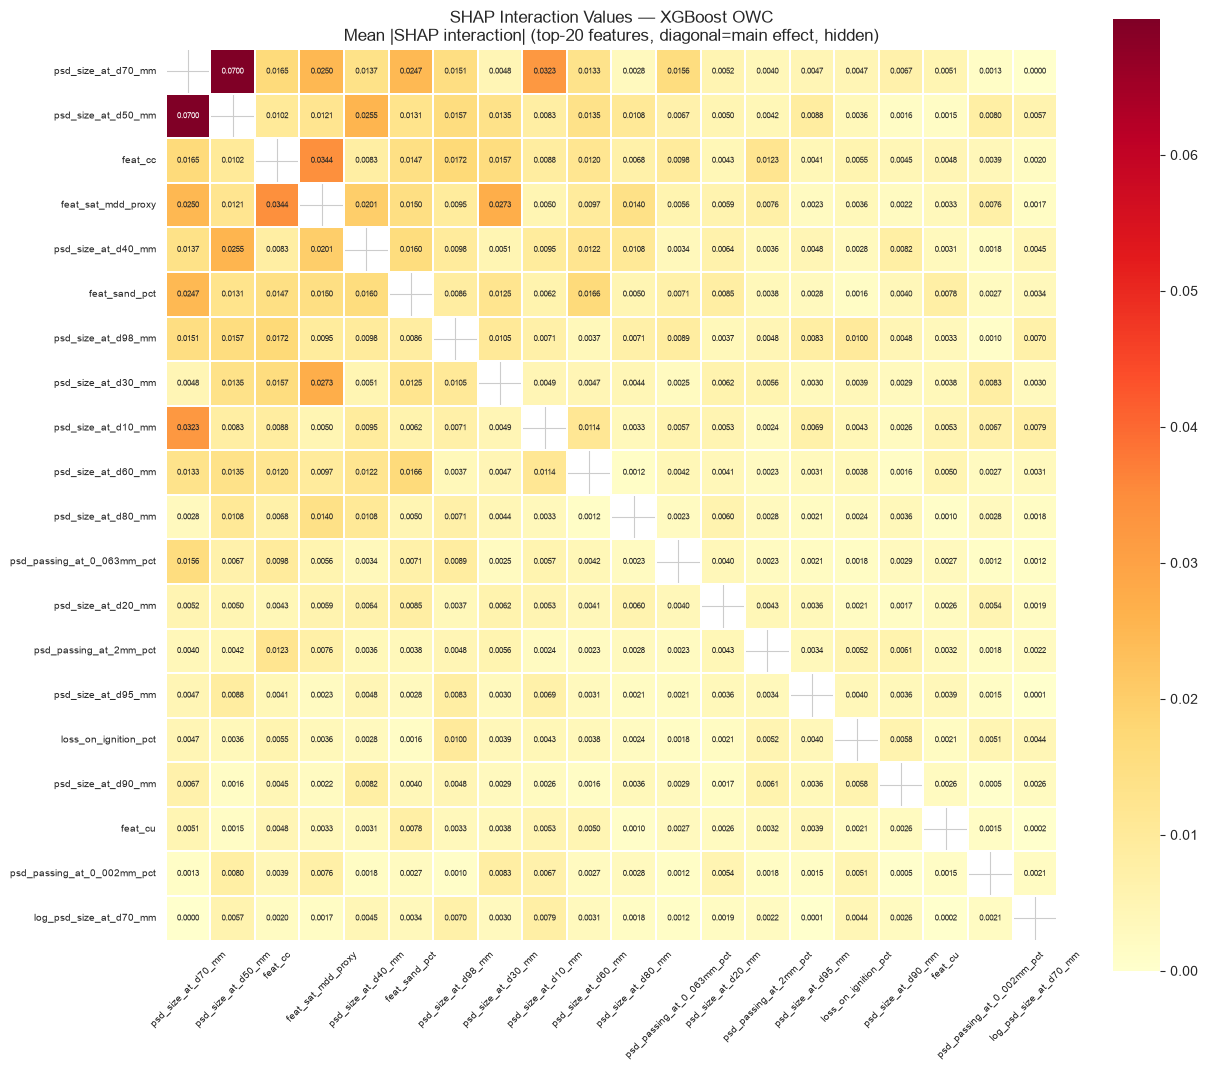


OWC — Top-10 SHAP interaction pairs:
  psd_size_at_d70_mm  ×  psd_size_at_d50_mm  =  0.06999
  feat_cc  ×  feat_sat_mdd_proxy  =  0.03435
  psd_size_at_d70_mm  ×  psd_size_at_d10_mm  =  0.03229
  feat_sat_mdd_proxy  ×  psd_size_at_d30_mm  =  0.02730
  psd_size_at_d50_mm  ×  psd_size_at_d40_mm  =  0.02546
  psd_size_at_d70_mm  ×  feat_sat_mdd_proxy  =  0.02501
  psd_size_at_d70_mm  ×  feat_sand_pct  =  0.02466
  feat_sat_mdd_proxy  ×  psd_size_at_d40_mm  =  0.02007
  feat_cc  ×  psd_size_at_d98_mm  =  0.01722
  feat_sand_pct  ×  psd_size_at_d60_mm  =  0.01661


In [13]:

# shap_interaction_values: exact pairwise SHAP interactions for tree models
print('Computing SHAP interaction values (XGBoost MDD & OWC)...')
siv_mdd = explainer_xgb_mdd.shap_interaction_values(X_train_df)  # (n, F, F)
siv_owc = explainer_xgb_owc.shap_interaction_values(X_train_df)
print(f'Interaction tensor shape: {siv_mdd.shape}')

# Mean |interaction| across samples → (F × F) matrix
mean_siv_mdd = np.abs(siv_mdd).mean(axis=0)
mean_siv_owc = np.abs(siv_owc).mean(axis=0)

# Zero out diagonal (main effects) to isolate interaction signal
np.fill_diagonal(mean_siv_mdd, 0)
np.fill_diagonal(mean_siv_owc, 0)

# Select top-20 features by total interaction strength for readability
for target_label, msiv in [('MDD', mean_siv_mdd), ('OWC', mean_siv_owc)]:
    row_sum = msiv.sum(axis=1)
    top_idx  = np.argsort(row_sum)[::-1][:20]
    top_feats = [FEATURE_COLS[i] for i in top_idx]
    sub = pd.DataFrame(msiv[np.ix_(top_idx, top_idx)], index=top_feats, columns=top_feats)

    fig, ax = plt.subplots(figsize=(13, 11))
    mask = np.eye(len(sub), dtype=bool)
    sns.heatmap(sub, mask=mask, annot=True, fmt='.4f', cmap='YlOrRd',
                linewidths=0.3, ax=ax, annot_kws={'size': 6}, square=True)
    ax.set_title(f'SHAP Interaction Values — XGBoost {target_label}\n'
                 f'Mean |SHAP interaction| (top-20 features, diagonal=main effect, hidden)',
                 fontsize=12)
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    ax.tick_params(axis='y', labelsize=7, rotation=0)
    plt.tight_layout()
    plt.show()

    pairs = [(top_feats[i], top_feats[j], sub.iloc[i, j])
             for i in range(len(top_feats)) for j in range(i+1, len(top_feats))]
    top_pairs = sorted(pairs, key=lambda x: -x[2])[:10]
    print(f'\n{target_label} — Top-10 SHAP interaction pairs:')
    for a, b, v in top_pairs:
        print(f'  {a}  ×  {b}  =  {v:.5f}')

# Store top pairs for Section 12
top_shap_pairs_mdd = sorted(
    [(FEATURE_COLS[i], FEATURE_COLS[j], mean_siv_mdd[i, j])
     for i in range(len(FEATURE_COLS)) for j in range(i+1, len(FEATURE_COLS))],
    key=lambda x: -x[2]
)[:5]
top_shap_pairs_owc = sorted(
    [(FEATURE_COLS[i], FEATURE_COLS[j], mean_siv_owc[i, j])
     for i in range(len(FEATURE_COLS)) for j in range(i+1, len(FEATURE_COLS))],
    key=lambda x: -x[2]
)[:5]


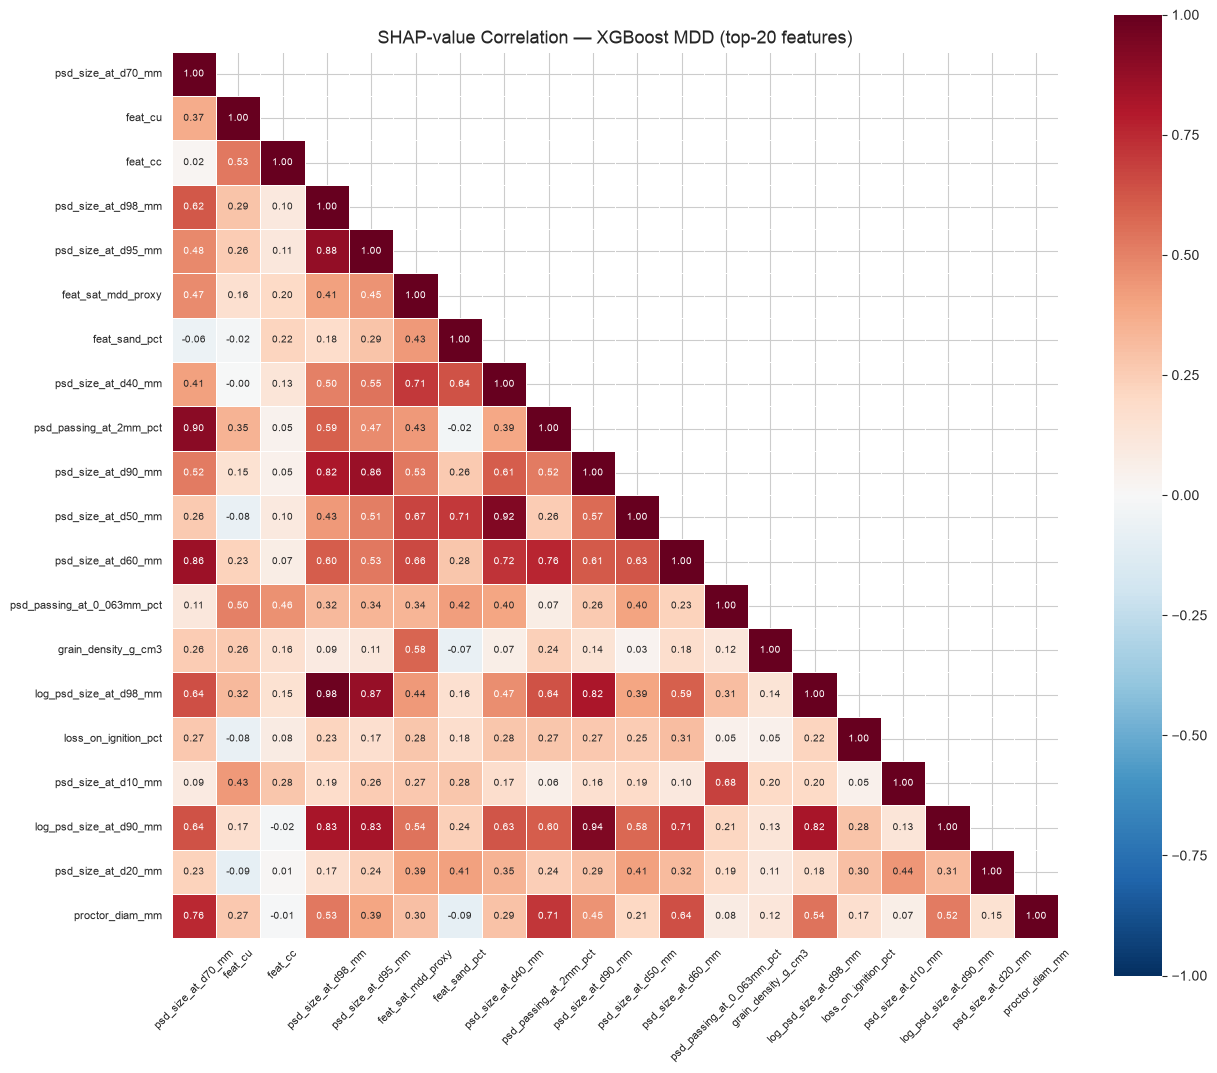


MDD — Highly correlated SHAP pairs (|r|>0.8):
  psd_size_at_d98_mm  ↔  log_psd_size_at_d98_mm  r=0.978
  psd_size_at_d90_mm  ↔  log_psd_size_at_d90_mm  r=0.935
  psd_size_at_d40_mm  ↔  psd_size_at_d50_mm  r=0.925
  psd_size_at_d70_mm  ↔  psd_passing_at_2mm_pct  r=0.904
  psd_size_at_d98_mm  ↔  psd_size_at_d95_mm  r=0.878
  psd_size_at_d95_mm  ↔  log_psd_size_at_d98_mm  r=0.871
  psd_size_at_d95_mm  ↔  psd_size_at_d90_mm  r=0.863
  psd_size_at_d70_mm  ↔  psd_size_at_d60_mm  r=0.857
  psd_size_at_d95_mm  ↔  log_psd_size_at_d90_mm  r=0.833
  psd_size_at_d98_mm  ↔  log_psd_size_at_d90_mm  r=0.825
  log_psd_size_at_d98_mm  ↔  log_psd_size_at_d90_mm  r=0.821
  psd_size_at_d90_mm  ↔  log_psd_size_at_d98_mm  r=0.82
  psd_size_at_d98_mm  ↔  psd_size_at_d90_mm  r=0.819


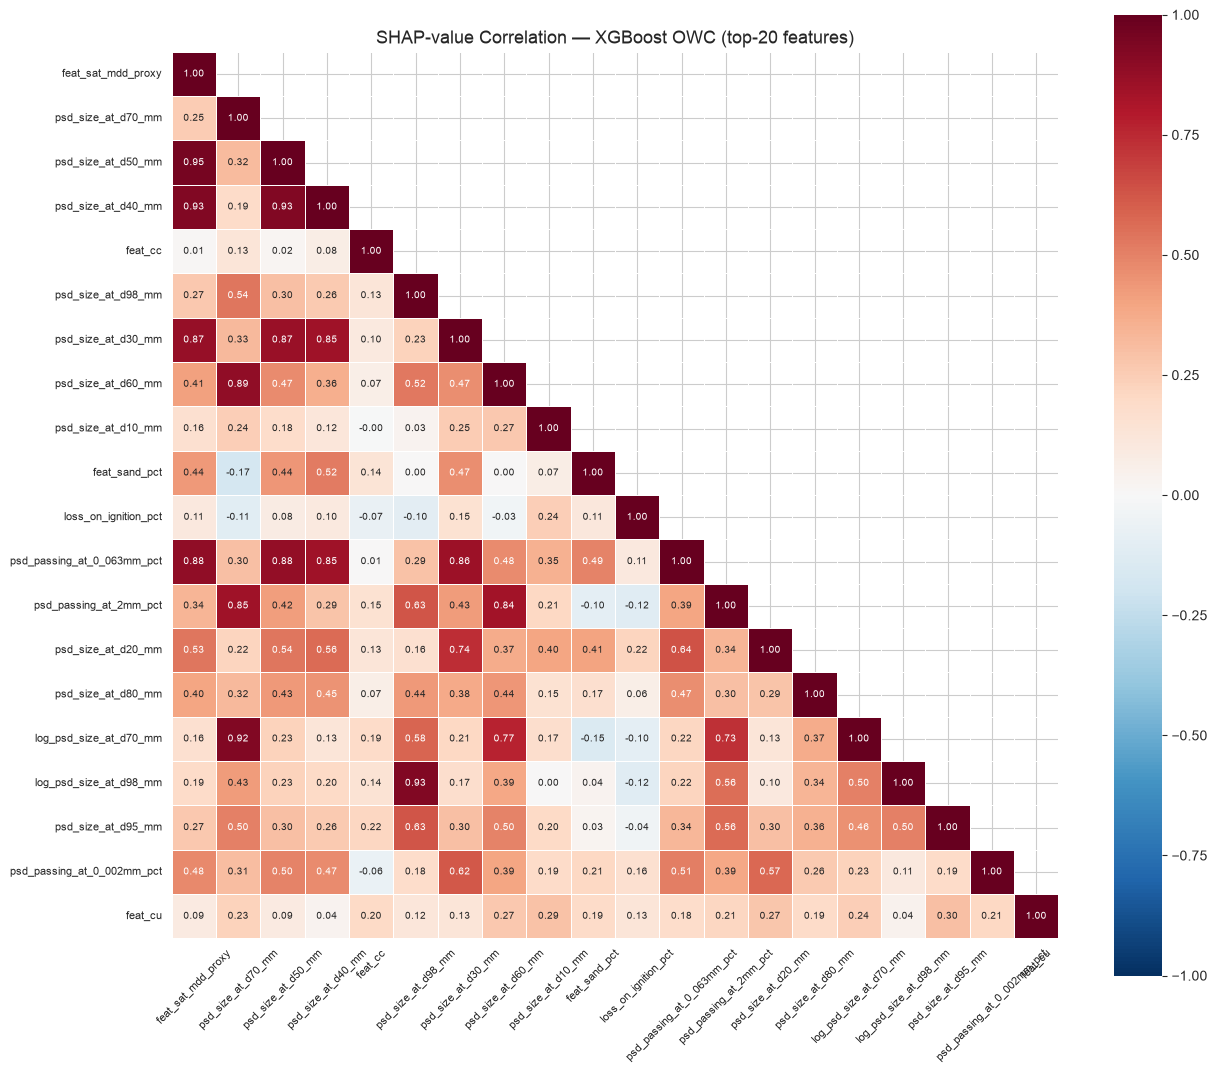


OWC — Highly correlated SHAP pairs (|r|>0.8):
  feat_sat_mdd_proxy  ↔  psd_size_at_d50_mm  r=0.953
  psd_size_at_d50_mm  ↔  psd_size_at_d40_mm  r=0.928
  psd_size_at_d98_mm  ↔  log_psd_size_at_d98_mm  r=0.928
  feat_sat_mdd_proxy  ↔  psd_size_at_d40_mm  r=0.927
  psd_size_at_d70_mm  ↔  log_psd_size_at_d70_mm  r=0.925
  psd_size_at_d70_mm  ↔  psd_size_at_d60_mm  r=0.886
  feat_sat_mdd_proxy  ↔  psd_passing_at_0_063mm_pct  r=0.883
  psd_size_at_d50_mm  ↔  psd_passing_at_0_063mm_pct  r=0.881
  feat_sat_mdd_proxy  ↔  psd_size_at_d30_mm  r=0.87
  psd_size_at_d50_mm  ↔  psd_size_at_d30_mm  r=0.867
  psd_size_at_d30_mm  ↔  psd_passing_at_0_063mm_pct  r=0.857
  psd_size_at_d40_mm  ↔  psd_passing_at_0_063mm_pct  r=0.85
  psd_size_at_d40_mm  ↔  psd_size_at_d30_mm  r=0.849
  psd_size_at_d70_mm  ↔  psd_passing_at_2mm_pct  r=0.847
  psd_size_at_d60_mm  ↔  psd_passing_at_2mm_pct  r=0.841


In [14]:
def shap_correlation_matrix(sv, feature_names, top_n=25):
    """Pearson correlation of per-sample SHAP value vectors."""
    df_shap = pd.DataFrame(sv.values, columns=feature_names)
    mean_abs = df_shap.abs().mean().sort_values(ascending=False)
    top_cols  = mean_abs.head(top_n).index.tolist()
    return df_shap[top_cols].corr(), top_cols

for target_label, sv in [('MDD', sv_xgb_mdd), ('OWC', sv_xgb_owc)]:
    corr_mat, cols = shap_correlation_matrix(sv, FEATURE_COLS, top_n=20)

    fig, ax = plt.subplots(figsize=(13, 11))
    mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
    sns.heatmap(
        corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
        vmin=-1, vmax=1, linewidths=0.4, ax=ax,
        annot_kws={'size': 7}, square=True
    )
    ax.set_title(f'SHAP-value Correlation — XGBoost {target_label} (top-20 features)', fontsize=13)
    ax.tick_params(axis='x', labelsize=8, rotation=45)
    ax.tick_params(axis='y', labelsize=8, rotation=0)
    plt.tight_layout()
    plt.show()

    high = []
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = corr_mat.iloc[i, j]
            if abs(r) > 0.8:
                high.append((cols[i], cols[j], round(r, 3)))
    if high:
        print(f'\n{target_label} — Highly correlated SHAP pairs (|r|>0.8):')
        for a, b, r in sorted(high, key=lambda x: -abs(x[2])):
            print(f'  {a}  ↔  {b}  r={r}')
    else:
        print(f'\n{target_label} — No SHAP pairs with |r|>0.8 found.')


---
## Section 9: SHAPIQ — Pairwise Feature Interaction Indices (k-SII)
SHAPIQ computes k-Shapley Interaction Values (k-SII) which decompose model output
into main effects and pairwise (or higher-order) interaction terms.

- **Main effect** `(i,)`: how much feature *i* contributes on its own  
- **Pairwise interaction** `(i,j)`: how much features *i* and *j* together shift the prediction **beyond** their individual contributions

A large `|k-SII(i,j)|` means the two features *interact* in the model — removing one changes how much the other matters.

> We use `shapiq.TabularExplainer` (model-agnostic, sampling-based) which correctly returns order-2 pairs.


In [15]:

# SHAPIQ k-SII pairwise interactions via TabularExplainer
# Uses model-agnostic sampling — works for any sklearn-compatible estimator.
# We explain a small representative subset for speed.
N_EXPLAIN = min(30, len(X_train))
X_explain_np = X_train[:N_EXPLAIN]   # numpy array required

def xgb_predict_mdd(x): return xgb_mdd.predict(x)
def xgb_predict_owc(x): return xgb_owc.predict(x)

print(f'Computing SHAPIQ k-SII (order=2) on {N_EXPLAIN} samples...')

shapiq_expl_mdd = shapiq.TabularExplainer(
    model=xgb_predict_mdd, data=X_explain_np, index='k-SII', max_order=2
)
shapiq_expl_owc = shapiq.TabularExplainer(
    model=xgb_predict_owc, data=X_explain_np, index='k-SII', max_order=2
)

interactions_mdd = shapiq_expl_mdd.explain_X(X_explain_np, budget=512)
interactions_owc = shapiq_expl_owc.explain_X(X_explain_np, budget=512)
print(f'Done: {len(interactions_mdd)} InteractionValues objects per target.')
print(f'Order-2 pairs per sample: '
      f'{sum(1 for k in interactions_mdd[0].interaction_lookup if len(k)==2)}')


Computing SHAPIQ k-SII (order=2) on 30 samples...
Done: 30 InteractionValues objects per target.
Order-2 pairs per sample: 1176


In [16]:

def build_interaction_df(interactions, feature_names, top_n_feats=20):
    """Average |k-SII| pairwise interaction matrix across all explained samples."""
    n = len(feature_names)
    mat = np.zeros((n, n))
    for iv in interactions:
        for key, idx in iv.interaction_lookup.items():
            if len(key) == 2:
                i, j = key
                v = abs(iv.values[idx])
                mat[i, j] += v
                mat[j, i] += v
    mat /= len(interactions)

    df_mat  = pd.DataFrame(mat, index=feature_names, columns=feature_names)
    row_sum = df_mat.sum(axis=1).sort_values(ascending=False)
    top     = row_sum.head(top_n_feats).index.tolist()
    return df_mat.loc[top, top], row_sum

imat_mdd, row_mdd = build_interaction_df(interactions_mdd, FEATURE_COLS)
imat_owc, row_owc = build_interaction_df(interactions_owc, FEATURE_COLS)

print('Interaction matrices built.')
print('\nTop-10 most-interacting features (MDD):')
print(row_mdd.head(10).round(6))


Interaction matrices built.

Top-10 most-interacting features (MDD):
hyd_cond_hyd_gradient_missing          28.778080
atterberg_plastic_limit_pct            27.732124
feat_sat_mdd_proxy                     27.308722
log_psd_size_at_d30_mm                 27.017400
feat_gravel_pct                        26.828024
log_psd_size_at_d50_mm                 26.160656
log_psd_size_at_d20_mm                 26.121342
psd_passing_at_0_063mm_pct             25.898690
log_psd_size_at_d98_mm                 25.238243
atterberg_plastic_limit_pct_missing    25.187463
dtype: float64


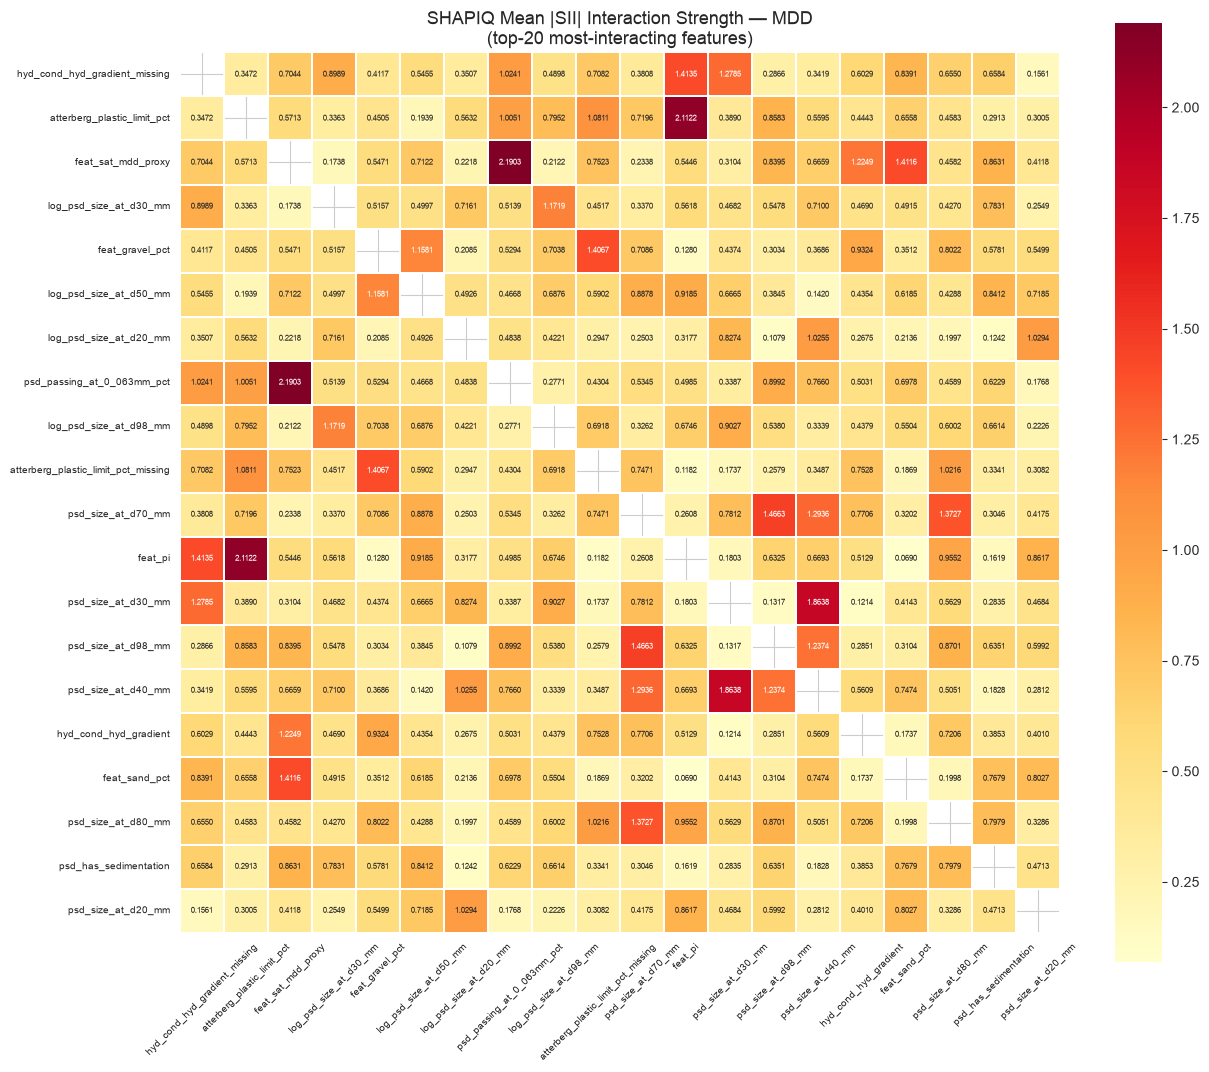


MDD — Top-10 feature interaction pairs (mean |SII|):
  feat_sat_mdd_proxy  ×  psd_passing_at_0_063mm_pct  =  2.19028
  atterberg_plastic_limit_pct  ×  feat_pi  =  2.11217
  psd_size_at_d30_mm  ×  psd_size_at_d40_mm  =  1.86381
  psd_size_at_d70_mm  ×  psd_size_at_d98_mm  =  1.46631
  hyd_cond_hyd_gradient_missing  ×  feat_pi  =  1.41352
  feat_sat_mdd_proxy  ×  feat_sand_pct  =  1.41161
  feat_gravel_pct  ×  atterberg_plastic_limit_pct_missing  =  1.40672
  psd_size_at_d70_mm  ×  psd_size_at_d80_mm  =  1.37271
  psd_size_at_d70_mm  ×  psd_size_at_d40_mm  =  1.29361
  hyd_cond_hyd_gradient_missing  ×  psd_size_at_d30_mm  =  1.27853


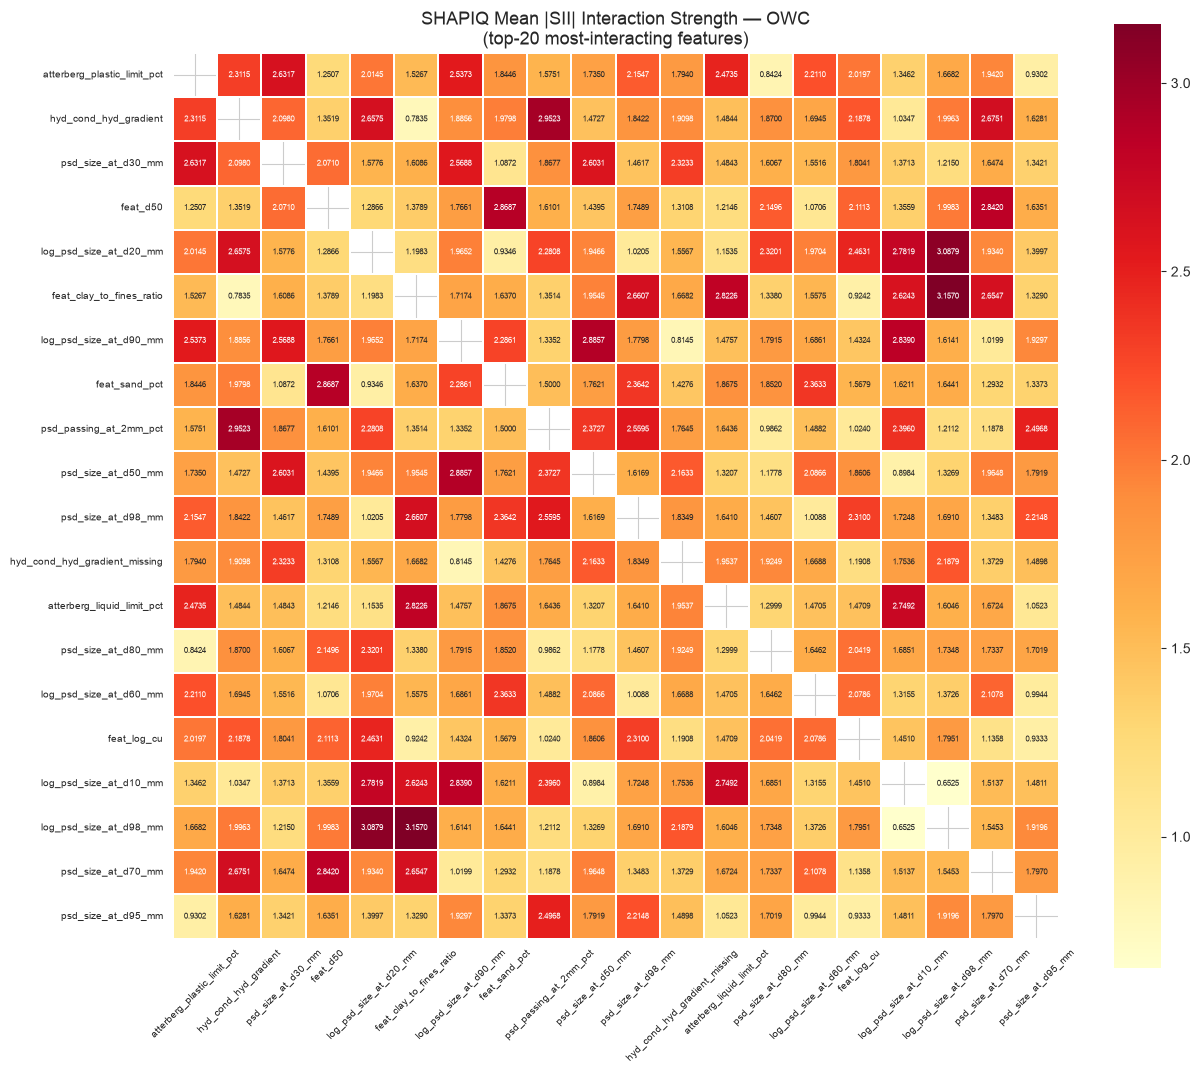


OWC — Top-10 feature interaction pairs (mean |SII|):
  feat_clay_to_fines_ratio  ×  log_psd_size_at_d98_mm  =  3.15703
  log_psd_size_at_d20_mm  ×  log_psd_size_at_d98_mm  =  3.08785
  hyd_cond_hyd_gradient  ×  psd_passing_at_2mm_pct  =  2.95231
  log_psd_size_at_d90_mm  ×  psd_size_at_d50_mm  =  2.88567
  feat_d50  ×  feat_sand_pct  =  2.86868
  feat_d50  ×  psd_size_at_d70_mm  =  2.84197
  log_psd_size_at_d90_mm  ×  log_psd_size_at_d10_mm  =  2.83905
  feat_clay_to_fines_ratio  ×  atterberg_liquid_limit_pct  =  2.82259
  log_psd_size_at_d20_mm  ×  log_psd_size_at_d10_mm  =  2.78189
  atterberg_liquid_limit_pct  ×  log_psd_size_at_d10_mm  =  2.74917


In [17]:
# Heatmap: mean |SII| pairwise interaction strength
try:
    for target_label, imat in [('MDD', imat_mdd), ('OWC', imat_owc)]:
        fig, ax = plt.subplots(figsize=(13, 11))
        mask = np.eye(len(imat), dtype=bool)   # hide diagonal (self-interaction = main effect)
        sns.heatmap(
            imat, mask=mask, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.3, ax=ax, annot_kws={'size': 6}, square=True
        )
        ax.set_title(f'SHAPIQ Mean |SII| Interaction Strength — {target_label}\n'
                     f'(top-20 most-interacting features)', fontsize=13)
        ax.tick_params(axis='x', labelsize=7, rotation=45)
        ax.tick_params(axis='y', labelsize=7, rotation=0)
        plt.tight_layout()
        plt.show()

        # Top pairs
        pairs = []
        cols_ = imat.columns.tolist()
        for i in range(len(cols_)):
            for j in range(i+1, len(cols_)):
                pairs.append((cols_[i], cols_[j], imat.iloc[i, j]))
        top_pairs = sorted(pairs, key=lambda x: -x[2])[:10]
        print(f'\n{target_label} — Top-10 feature interaction pairs (mean |SII|):')
        for a, b, v in top_pairs:
            print(f'  {a}  ×  {b}  =  {v:.5f}')
except Exception as e:
    print(f'Heatmap skipped: {e}')

---
## Section 10: SHAPIQ Network Graph — Feature Interaction Topology
Nodes = features, edge weight = mean |SII|. Helps visualise which feature clusters interact.

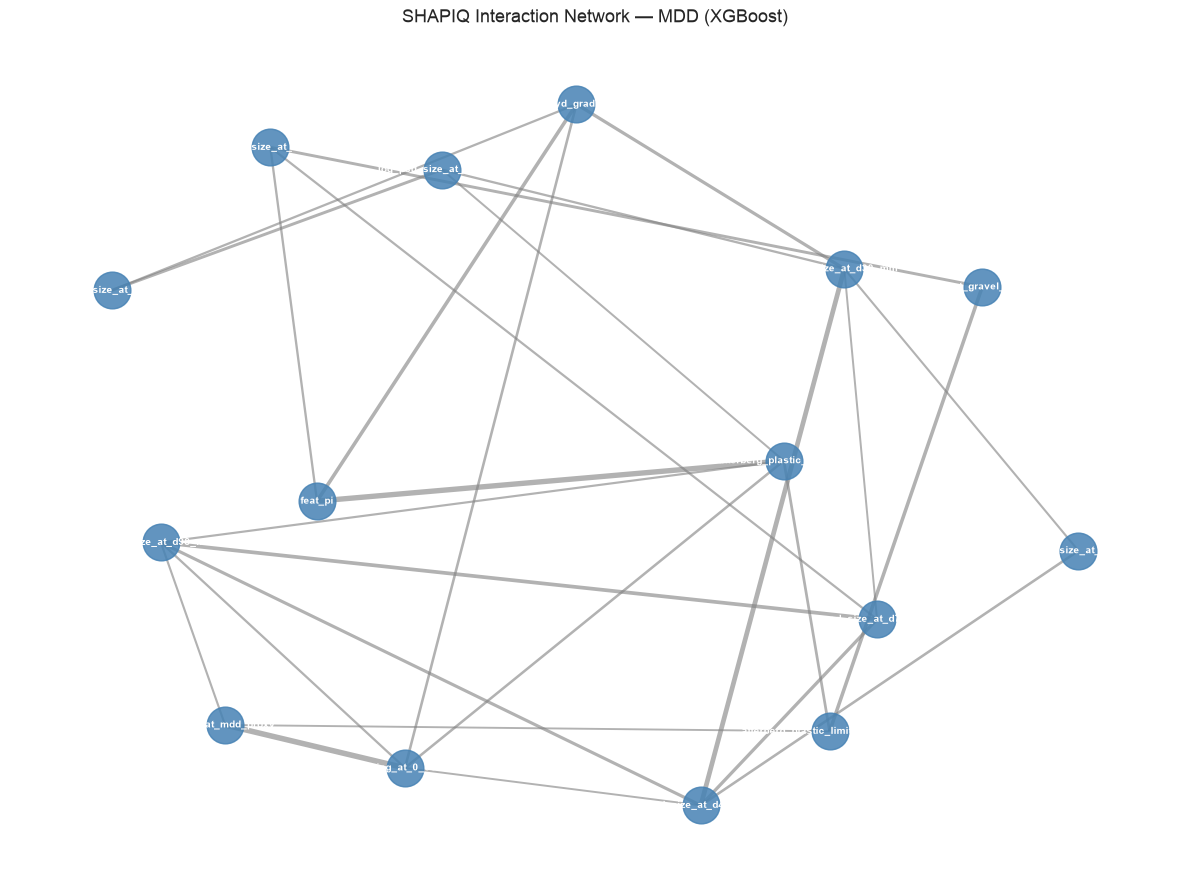

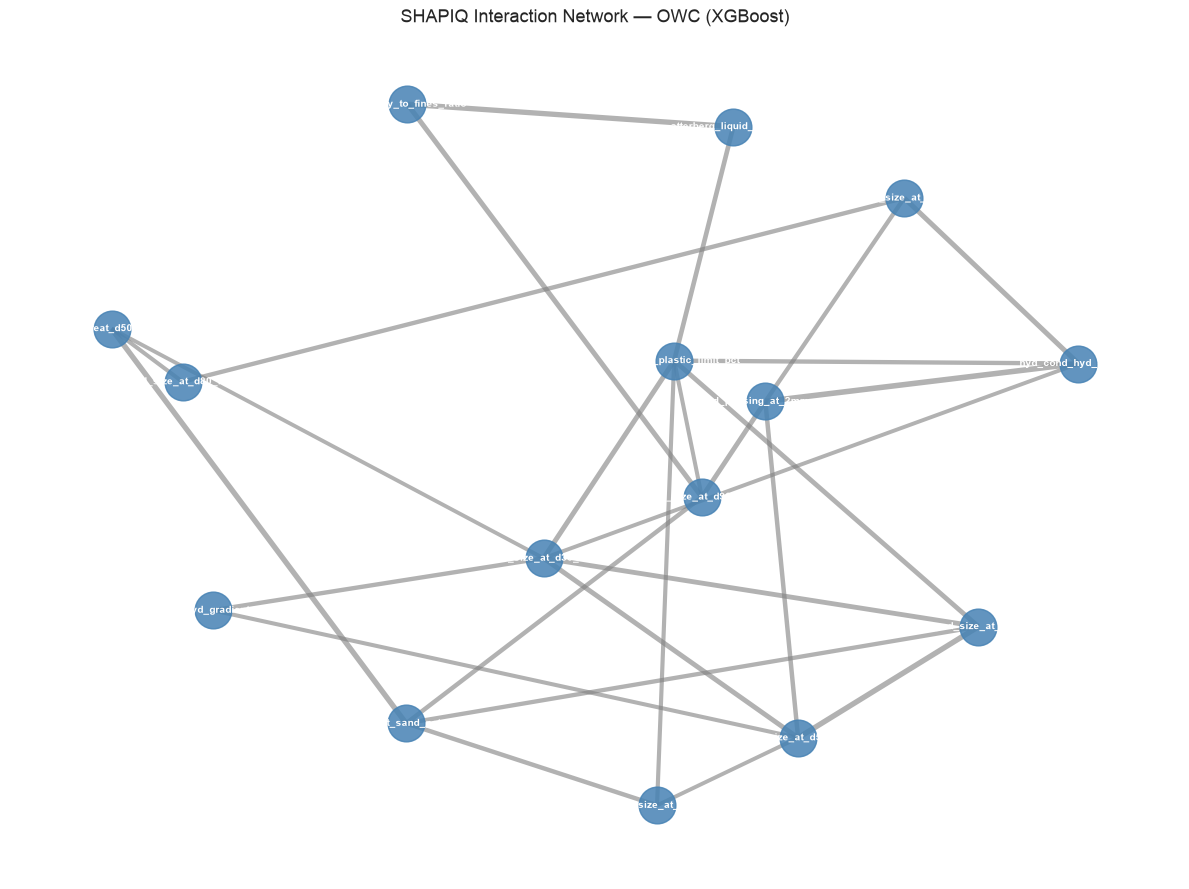

In [18]:
import networkx as nx

def draw_interaction_network(imat, title, top_n=15, threshold_quantile=0.75):
    sub = imat.head(top_n).iloc[:, :top_n]
    G = nx.Graph()
    cols_ = sub.columns.tolist()
    G.add_nodes_from(cols_)

    vals = [sub.iloc[i, j] for i in range(len(cols_)) for j in range(i+1, len(cols_))]
    threshold = np.quantile(vals, threshold_quantile) if vals else 0

    for i in range(len(cols_)):
        for j in range(i+1, len(cols_)):
            w = sub.iloc[i, j]
            if w >= threshold:
                G.add_edge(cols_[i], cols_[j], weight=w)

    weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_w   = max(weights) if weights else 1
    edge_w  = [4 * w / max_w for w in weights]

    pos = nx.spring_layout(G, seed=42, k=2.5)
    fig, ax = plt.subplots(figsize=(12, 9))
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=700, node_color='steelblue', alpha=0.85)
    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_w, alpha=0.6, edge_color='grey')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_color='white', font_weight='bold')
    ax.set_title(title, fontsize=13)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

try:
    draw_interaction_network(imat_mdd, 'SHAPIQ Interaction Network — MDD (XGBoost)')
    draw_interaction_network(imat_owc, 'SHAPIQ Interaction Network — OWC (XGBoost)')
except Exception as e:
    print(f'Network graph skipped: {e}')

---
## Section 11: Feature Selection via SHAP — Reduced Feature Set
Drop features whose mean |SHAP| is below a cutoff to test if a leaner model generalises better.

In [19]:
# Cutoff: keep features where mean |SHAP| across all 4 model×target combos > 1% of max
shap_threshold = shap_imp['mean_all'].max() * 0.01
selected_feats  = shap_imp[shap_imp['mean_all'] >= shap_threshold].index.tolist()

print(f'Threshold: {shap_threshold:.5f}')
print(f'Features retained: {len(selected_feats)} / {len(FEATURE_COLS)}')
dropped = [f for f in FEATURE_COLS if f not in selected_feats]
print(f'Dropped: {dropped}')

feat_idx_sel = [FEATURE_COLS.index(f) for f in selected_feats]
X_train_sel  = X_train[:, feat_idx_sel]
X_test_sel   = X_test[:,  feat_idx_sel]

print('\n--- 5-fold CV: XGBoost (SHAP-selected features) ---')
xgb_mdd_sel = xgb.XGBRegressor(**xgb_params)
xgb_owc_sel = xgb.XGBRegressor(**xgb_params)
xgb_sel_scores = cv_nmae(xgb_mdd_sel, xgb_owc_sel, X_train_sel, y_mdd, y_owc, label='XGB-sel')

print(f'\nAll features:       {np.mean(xgb_scores):.4f}')
print(f'SHAP-selected ({len(selected_feats)}): {np.mean(xgb_sel_scores):.4f}')

Threshold: 0.00326
Features retained: 41 / 49
Dropped: ['atterberg_liquid_limit_pct', 'atterberg_plastic_limit_pct', 'atterberg_liquid_limit_pct_missing', 'atterberg_plastic_limit_pct_missing', 'hyd_cond_hyd_gradient_missing', 'feat_pi', 'feat_soil_type', 'log_psd_size_at_d50_mm']

--- 5-fold CV: XGBoost (SHAP-selected features) ---
  [XGB-sel] Fold 1: 0.2606
  [XGB-sel] Fold 2: 0.2483
  [XGB-sel] Fold 3: 0.2651
  [XGB-sel] Fold 4: 0.2928
  [XGB-sel] Fold 5: 0.2255
  Mean: 0.2585 ± 0.0220

All features:       0.2612
SHAP-selected (41): 0.2585


---
## Section 12: SHAPIQ — Interaction-aware Feature Pairs as New Features
The highest-SII pairs are likely to benefit from explicit interaction terms.
Add them as product features and re-evaluate.

In [20]:

def add_interaction_features(X_df, top_pairs, feature_names):
    df = X_df.copy()
    new_cols = []
    for a, b, _ in top_pairs:
        col_name = f'inter_{a}_x_{b}'
        df[col_name] = df[a].values * df[b].values
        new_cols.append(col_name)
    return df, new_cols

# Use SHAP interaction values (exact, tree-native) to identify which pairs to add
top5_combined = list({(a, b): v for a, b, v in top_shap_pairs_mdd + top_shap_pairs_owc}.items())
top5_combined = [(a, b, v) for (a, b), v in top5_combined][:5]

print('Interaction product features derived from SHAP interaction values:')
for a, b, v in top5_combined:
    print(f'  {a} × {b}  (mean |SHAP interaction|={v:.5f})')

train_fe_inter, new_cols = add_interaction_features(X_train_df, top5_combined, FEATURE_COLS)
test_fe_inter,  _        = add_interaction_features(X_test_df,  top5_combined, FEATURE_COLS)

FEATURE_COLS_INTER = FEATURE_COLS + new_cols
X_train_inter = train_fe_inter[FEATURE_COLS_INTER].values.astype(np.float32)
X_test_inter  = test_fe_inter[FEATURE_COLS_INTER].values.astype(np.float32)

print(f'\nNew feature matrix: {X_train_inter.shape}')
print('\n--- 5-fold CV: XGBoost + SHAP-interaction features ---')
xgb_mdd_inter = xgb.XGBRegressor(**xgb_params)
xgb_owc_inter = xgb.XGBRegressor(**xgb_params)
xgb_inter_scores = cv_nmae(xgb_mdd_inter, xgb_owc_inter,
                            X_train_inter, y_mdd, y_owc, label='XGB+inter')

print(f'\nBaseline XGB:         {np.mean(xgb_scores):.4f}')
print(f'+ interaction feats:  {np.mean(xgb_inter_scores):.4f}')
interaction_features_available = True


Interaction product features derived from SHAP interaction values:
  psd_size_at_d70_mm × feat_cc  (mean |SHAP interaction|=0.00202)
  psd_size_at_d90_mm × feat_cc  (mean |SHAP interaction|=0.00176)
  psd_size_at_d95_mm × feat_cc  (mean |SHAP interaction|=0.00148)
  psd_size_at_d70_mm × feat_cu  (mean |SHAP interaction|=0.00139)
  psd_passing_at_2mm_pct × feat_cc  (mean |SHAP interaction|=0.00131)

New feature matrix: (201, 54)

--- 5-fold CV: XGBoost + SHAP-interaction features ---
  [XGB+inter] Fold 1: 0.2582
  [XGB+inter] Fold 2: 0.2505
  [XGB+inter] Fold 3: 0.2740
  [XGB+inter] Fold 4: 0.2810
  [XGB+inter] Fold 5: 0.2104
  Mean: 0.2548 ± 0.0247

Baseline XGB:         0.2612
+ interaction feats:  0.2548


---
## Section 13: Local Explanation — Waterfall & Force Plots
Explain individual predictions to understand *why* a specific sample gets its predicted value.

Low MDD sample:    idx=119   pred=1.639  true=1.609
Median MDD sample: idx=111 pred=2.003  true=2.013
High MDD sample:   idx=27  pred=2.198  true=2.192

--- Waterfall: MDD prediction for LOW sample (idx=119) ---


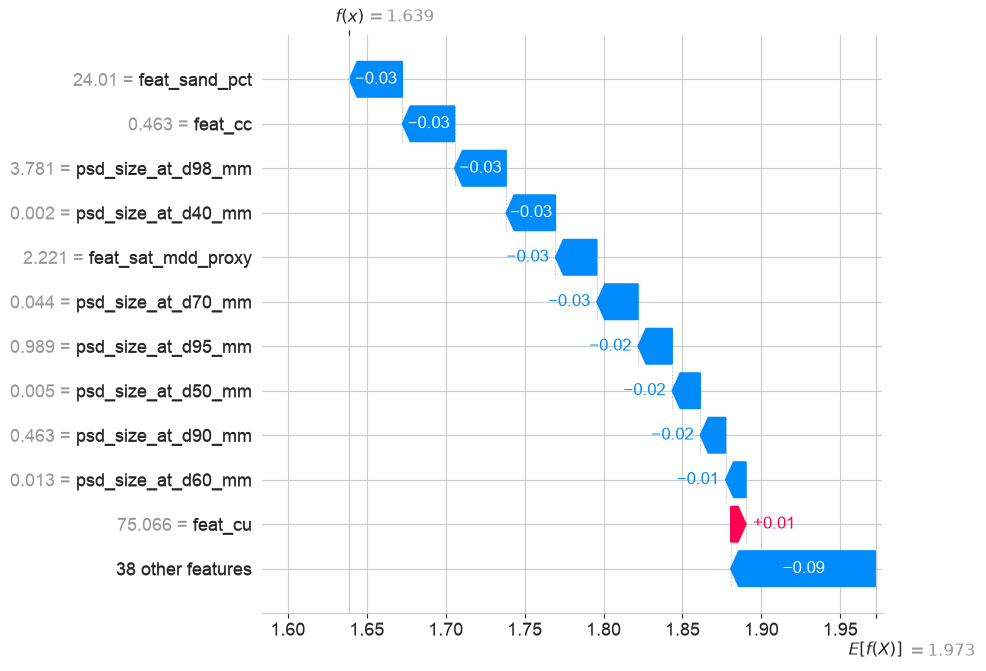


--- Waterfall: MDD prediction for MEDIAN sample (idx=111) ---


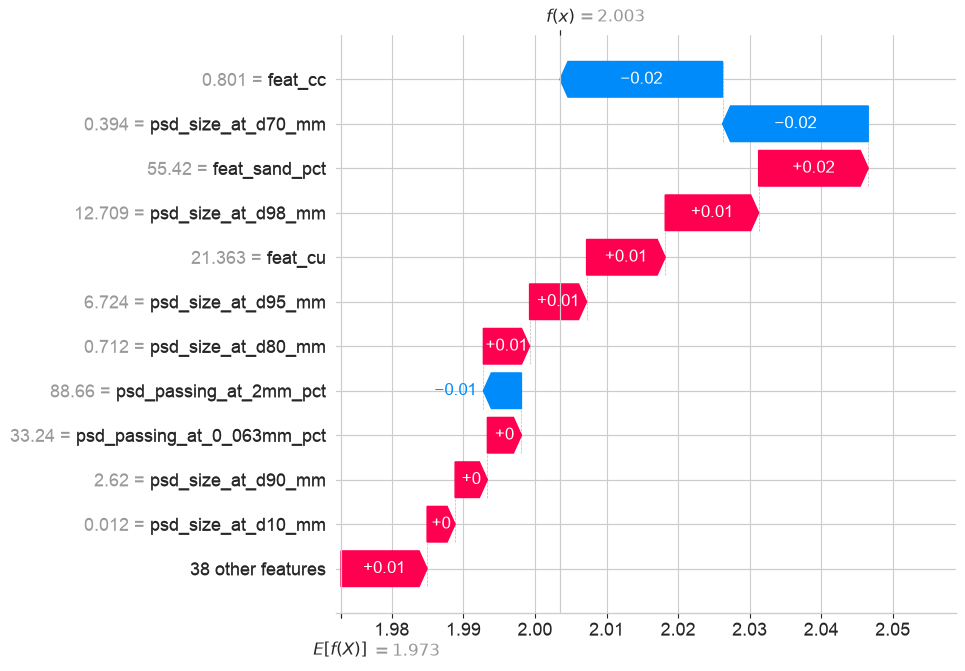


--- Waterfall: MDD prediction for HIGH sample (idx=27) ---


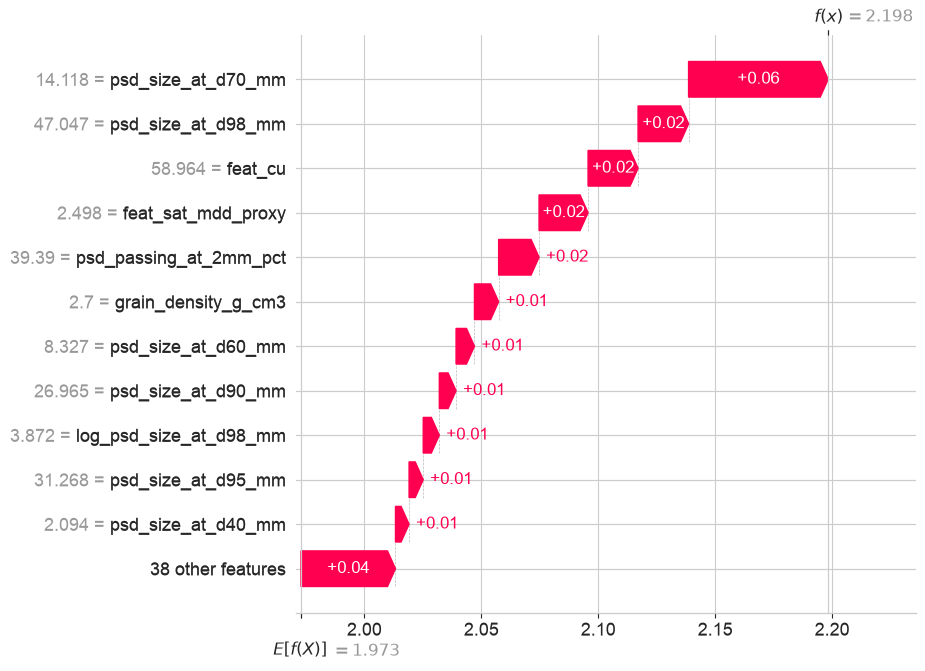

In [21]:
# Pick three representative samples: low / median / high MDD
y_pred_train_mdd = xgb_mdd.predict(X_train)
low_idx    = int(np.argmin(y_pred_train_mdd))
median_idx = int(np.argsort(y_pred_train_mdd)[len(y_pred_train_mdd)//2])
high_idx   = int(np.argmax(y_pred_train_mdd))

print(f'Low MDD sample:    idx={low_idx}   pred={y_pred_train_mdd[low_idx]:.3f}  true={y_mdd[low_idx]:.3f}')
print(f'Median MDD sample: idx={median_idx} pred={y_pred_train_mdd[median_idx]:.3f}  true={y_mdd[median_idx]:.3f}')
print(f'High MDD sample:   idx={high_idx}  pred={y_pred_train_mdd[high_idx]:.3f}  true={y_mdd[high_idx]:.3f}')

for idx, label in [(low_idx, 'LOW'), (median_idx, 'MEDIAN'), (high_idx, 'HIGH')]:
    print(f'\n--- Waterfall: MDD prediction for {label} sample (idx={idx}) ---')
    shap.plots.waterfall(sv_xgb_mdd[idx], max_display=12, show=True)

In [22]:
# Force plot — all training samples stacked (HTML, shown inline)
shap.initjs()
force_mdd = shap.force_plot(
    explainer_xgb_mdd.expected_value,
    sv_xgb_mdd.values,
    X_train_df,
    feature_names=FEATURE_COLS,
    show=False
)
shap.save_html('../docs/shap_force_mdd.html', force_mdd)
print('Force plot saved to docs/shap_force_mdd.html')

Force plot saved to docs/shap_force_mdd.html


---
## Section 14: Summary — SHAP & SHAPIQ Findings

In [23]:
print('=' * 65)
print('SHAP + SHAPIQ Analysis Summary')
print('=' * 65)

print('\n[1] Top-5 features by mean |SHAP| (MDD):')
for f, v in shap_imp['XGB_MDD'].nlargest(5).items():
    print(f'    {f:<40s}  {v:.4f}')

print('\n[2] Top-5 features by mean |SHAP| (OWC):')
for f, v in shap_imp['XGB_OWC'].nlargest(5).items():
    print(f'    {f:<40s}  {v:.4f}')

print('\n[3] CV NMAE comparison:')
print(f'    XGBoost (all {len(FEATURE_COLS)} features):   {np.mean(xgb_scores):.4f}')
print(f'    XGBoost (SHAP-selected {len(selected_feats)} feats):  {np.mean(xgb_sel_scores):.4f}')
if interaction_features_available:
    print(f'    XGBoost + SHAPIQ interactions:  {np.mean(xgb_inter_scores):.4f}')

print('\n[4] Key insight:')
if np.mean(xgb_sel_scores) < np.mean(xgb_scores):
    print(f'    SHAP-selected subset IMPROVES NMAE by '
          f'{np.mean(xgb_scores) - np.mean(xgb_sel_scores):.4f}.')
    print(f'    Recommend using {len(selected_feats)}-feature set in final model.')
else:
    print('    Full feature set performs equally or better; SHAP selection not beneficial here.')

print('\nForce plots: docs/shap_force_mdd.html')
print('=' * 65)

SHAP + SHAPIQ Analysis Summary

[1] Top-5 features by mean |SHAP| (MDD):
    psd_size_at_d70_mm                        0.0271
    feat_cu                                   0.0198
    feat_cc                                   0.0197
    psd_size_at_d98_mm                        0.0153
    psd_size_at_d95_mm                        0.0085

[2] Top-5 features by mean |SHAP| (OWC):
    feat_sat_mdd_proxy                        0.6194
    psd_size_at_d70_mm                        0.4418
    psd_size_at_d50_mm                        0.3317
    psd_size_at_d40_mm                        0.3225
    feat_cc                                   0.3001

[3] CV NMAE comparison:
    XGBoost (all 49 features):   0.2612
    XGBoost (SHAP-selected 41 feats):  0.2585
    XGBoost + SHAPIQ interactions:  0.2548

[4] Key insight:
    SHAP-selected subset IMPROVES NMAE by 0.0028.
    Recommend using 41-feature set in final model.

Force plots: docs/shap_force_mdd.html


---
## Section 15: Final Prediction & Submission

In [24]:
def apply_saturation_constraint(mdd_pred, owc_pred, grain_density, safety=0.99):
    rho_s  = grain_density
    w_frac = owc_pred / 100.0
    sat_limit = rho_s / (1 + w_frac * rho_s / RHO_W)
    return np.minimum(mdd_pred, sat_limit * safety)

# Pick best configuration from CV results
scores_map = {
    'all_feats':   np.mean(xgb_scores),
    'shap_select': np.mean(xgb_sel_scores),
}
if interaction_features_available:
    scores_map['inter_feats'] = np.mean(xgb_inter_scores)

best_config = min(scores_map, key=scores_map.get)
print(f'Best config: {best_config}  NMAE={scores_map[best_config]:.4f}')

if best_config == 'shap_select':
    X_tr_final, X_te_final = X_train_sel, X_test_sel
elif best_config == 'inter_feats':
    X_tr_final, X_te_final = X_train_inter, X_test_inter
else:
    X_tr_final, X_te_final = X_train, X_test

final_mdd = xgb.XGBRegressor(**xgb_params).fit(X_tr_final, y_mdd)
final_owc = xgb.XGBRegressor(**xgb_params).fit(X_tr_final, y_owc)

pred_mdd = final_mdd.predict(X_te_final)
pred_owc = final_owc.predict(X_te_final)

grain_dens_test = test_fe['grain_density_g_cm3'].values
pred_mdd = apply_saturation_constraint(pred_mdd, pred_owc, grain_dens_test)

submission = pd.DataFrame({
    'id':               test_raw['id'],
    'proctor_owc_pct':  pred_owc,
    'proctor_mdd_g_cm3': pred_mdd
})

assert list(submission.columns) == ['id', 'proctor_owc_pct', 'proctor_mdd_g_cm3']
assert len(submission) == len(test_raw)
assert (submission['proctor_mdd_g_cm3'] > 1.4).all()
assert (submission['proctor_mdd_g_cm3'] < 2.5).all()
assert (submission['proctor_owc_pct'] > 2.0).all()
assert (submission['proctor_owc_pct'] < 35.0).all()

timestamp = datetime.now().strftime('%Y%m%d_%H%M')
out_path  = f'../submissions/submission_{timestamp}_v2.csv'
submission.to_csv(out_path, index=False)
print(f'\nAll checks passed. Submission saved: {out_path}')
submission.describe().round(3)

Best config: inter_feats  NMAE=0.2548

All checks passed. Submission saved: ../submissions/submission_20260630_1449_v2.csv


,id,proctor_owc_pct,proctor_mdd_g_cm3
count,87.000,87.000,87.000
mean,244.000,9.929,1.978
std,25.259,3.023,0.119
min,201.000,6.032,1.700
25%,222.500,7.455,1.890
50%,244.000,9.564,2.002
75%,265.500,10.763,2.068
max,287.000,18.724,2.189
